In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

In [2]:
sys.path.append("../src")
from anomalies import TemporalAnomalyDetector


In [3]:
# Configuración de Rutas
BASE_DIR = Path.cwd().parent
CSV_CHATS = BASE_DIR / "data" / "processed" / "chats_completos.csv"

# Cargamos el Golden Dataset de la Fase 1
df_chats = pd.read_csv(CSV_CHATS)

In [4]:
# 2. Pipeline de Detección de Anomalías
# Fijamos un 4% de anomalías esperadas (ajustable según tu criterio forense)
detector = TemporalAnomalyDetector(contamination=0.04) 
df_prepared = detector.prepare_features(df_chats)

# Seleccionamos estrictamente variables de COMPORTAMIENTO (sin texto)
features_to_model = ['Hour', 'Message_Length', 'Time_Delta_Sec']

# Ejecución del Modelo Predictivo
df_anomalies = detector.fit_predict(df_prepared, features_to_model)

Realizando Feature Engineering temporal...
Entrenando Isolation Forest sobre 806 eventos...


In [5]:
# 3. Métricas Básicas
anomalos = df_anomalies[df_anomalies['Is_Anomaly'] == -1]
normales = df_anomalies[df_anomalies['Is_Anomaly'] == 1]

print(f"\n--- Resumen del Isolation Forest ---")
print(f"Total de eventos evaluados: {len(df_anomalies)}")
print(f"Comportamientos Normales: {len(normales)}")
print(f"Anomalías Detectadas (Crisis/Atípicos): {len(anomalos)}")


--- Resumen del Isolation Forest ---
Total de eventos evaluados: 806
Comportamientos Normales: 773
Anomalías Detectadas (Crisis/Atípicos): 33


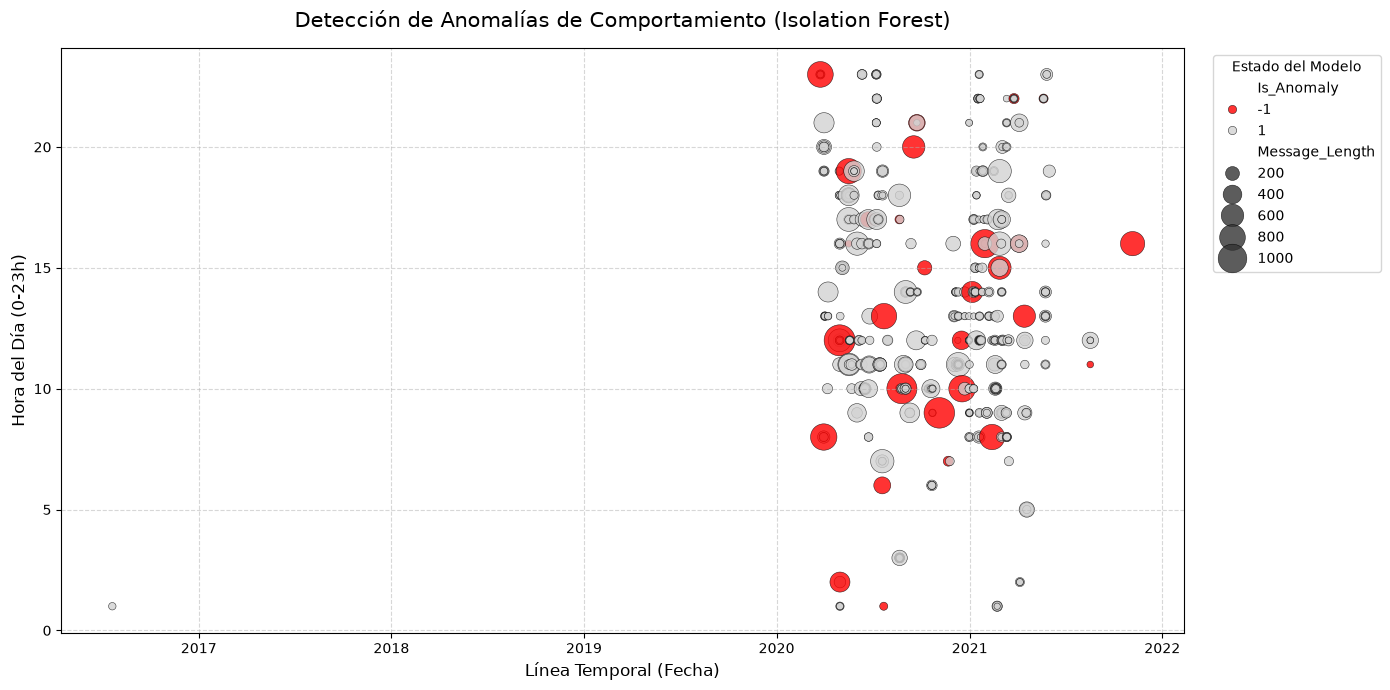

In [6]:
# 4. Visualización Forense (El Gráfico para la Defensa)
plt.figure(figsize=(14, 7))

# Gráfico de dispersión: Timeline vs Hora del Día
sns.scatterplot(
    data=df_anomalies, 
    x='Datetime', 
    y='Hour', 
    hue='Is_Anomaly', 
    palette={1: 'lightgrey', -1: 'red'}, # Rojos para las alertas
    size='Message_Length', # Burbujas grandes = mensajes muy largos (Testamentos)
    sizes=(20, 500),
    alpha=0.8,
    edgecolor='black'
)

plt.title('Detección de Anomalías de Comportamiento (Isolation Forest)', fontsize=15, pad=15)
plt.xlabel('Línea Temporal (Fecha)', fontsize=12)
plt.ylabel('Hora del Día (0-23h)', fontsize=12)

# Ajuste de la leyenda para que no manche los datos
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Estado del Modelo")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [7]:
# 5. Volcado Analítico del Top 10 Anomalías
columnas_mostrar = ['Datetime', 'Emisor', 'Hour', 'Message_Length', 'Time_Delta_Sec', 'Anomaly_Score', 'Mensaje']
top_anomalias = anomalos.sort_values(by='Anomaly_Score').head(10)

print("\n--- TOP 10 EVENTOS MÁS ANÓMALOS MATEMÁTICAMENTE (Mayor a Menor rareza) ---")
display(top_anomalias[columnas_mostrar])


--- TOP 10 EVENTOS MÁS ANÓMALOS MATEMÁTICAMENTE (Mayor a Menor rareza) ---


,Datetime,Emisor,Hour,Message_Length,Time_Delta_Sec,Anomaly_Score,Mensaje
1,2020-03-23 23:06:48,Miguel Palomero,23,36,115938777.0,-0.176916,Que vais a hacer con la línea aérea?
805,2021-11-05 16:04:54,JULIO MARTÍNEZ SOLA,16,705,6923797.0,-0.168359,Me acaba de llamar a José Ángel Partearroyo de...
410,2020-11-04 09:15:19,ROBERTO ROSELLI,9,1149,1119296.0,-0.166044,“Acabo de hablar con el tipo de la SEPI. Estáb...
801,2021-08-17 11:27:07,JULIO MARTINEZ MARTINEZ,11,9,6710211.0,-0.119281,dale duro
757,2021-05-20 22:32:47,Miguel Palomero,22,59,2739382.0,-0.100961,Mañana pregunto para que me digan de la juez d...
411,2020-11-21 07:52:44,Julio MARTINEZ SOLA,7,79,1463845.0,-0.086440,Tocayo Tienes que averiguar qué ASESOR está ll...
743,2021-04-14 13:02:29,ROBERTO ROSELLI,13,588,728111.0,-0.084518,"Mi querido y estimado gran amigo, que… me tien..."
364,2020-09-16 20:00:20,ROBERTO ROSELLI,20,598,444155.0,-0.083434,"“Por cierto, pana, hoy, nada yo estaba en una ..."
14,2020-03-23 23:18:09,Miguel Palomero,23,801,10.0,-0.072908,Creo que si (...) 5 Conversaciones entre Migue...
290,2020-08-20 17:23:45,ROBERTO ROSELLI,17,52,1920087.0,-0.071245,"Sale buzón le he dejado un mensaje, espero su ..."


In [8]:
CSV_TOP_CHATS = BASE_DIR / "data" / "processed" / "chats_top.csv"
top_anomalias[columnas_mostrar].to_csv(CSV_TOP_CHATS)